In [ ]:
# download dataset
!wget https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!wget https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

In [2]:
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

In [1]:
# load images and corresponding masks from directory

import os
import numpy as np
import keras

train_images = []
train_masks = []

for file in os.listdir("images"):
  # image files should have .jpg extension
  if not file.lower().endswith(".jpg"):
    continue

  image_file = os.path.join("images", file)

  # corresponding mask file path
  mask_file = os.path.join("annotations", "trimaps", file.split(".")[0] + ".png")

  # load input image
  image = keras.utils.load_img(image_file, target_size = (200, 200))
  train_images.append(image)

  # load mask
  masked_image = keras.utils.load_img(mask_file, target_size= (200, 200), color_mode='grayscale')
  train_masks.append(masked_image)

train_images = np.array(train_images[:5000])
train_masks = np.array(train_masks[:5000])

In [2]:
train_images.shape

(5000, 200, 200, 3)

In [3]:
train_masks.shape

(5000, 200, 200)

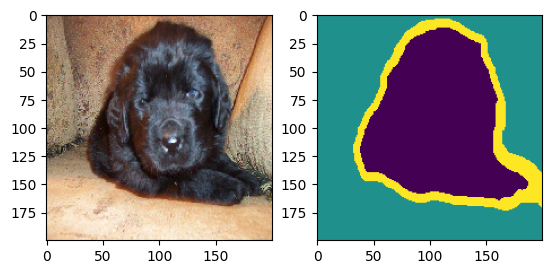

In [4]:
import matplotlib.pyplot as plt

# display sample image
plt.subplot(1, 2, 1)
plt.imshow(train_images[10])

# display corresponding mask
plt.subplot(1, 2, 2)
plt.imshow(train_masks[10])

In [5]:
# define model architecure

from keras import layers

inputs = layers.Input(shape=(200, 200, 3))
x = layers.Rescaling(1.0/255)(inputs)

# down-sampling
for k in (32, 64):
  x = layers.Conv2D(k, 3, strides = 2, padding = "same", activation = "relu")(x)

# bottle-neck layer
x = layers.Conv2D(128, 3, padding = 'same', activation = 'relu')(x)

# up-sampling
for k in (64, 32):
  x = layers.Conv2DTranspose(k, 3, strides = 2, padding = 'same', activation = 'relu')(x)

# output layer
outputs = layers.Conv2D(3, 3, padding = 'same', activation = 'softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 200, 200, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
# keras expects labels (0, 1, 2) instead of (1, 2, 3)
train_masks = train_masks - 1

In [ ]:
model.fit(train_images, train_masks, validation_split=0.3, epochs=5)

In [25]:
# load sample images to test segmentation output
test_image1 = keras.utils.load_img("test-1.png", target_size=(200, 200))
test_image2 =  keras.utils.load_img("test-2.png", target_size=(200, 200))

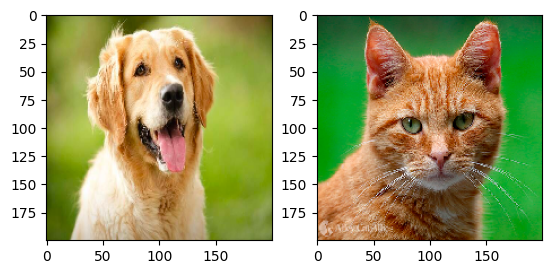

In [26]:
# display test images
plt.subplot(1, 2, 1)
plt.imshow(test_image1)

plt.subplot(1, 2, 2)
plt.imshow(test_image2)

In [27]:
# run model predictions on sample test images

y1 = model.predict(np.array([test_image1]))
y2 = model.predict(np.array([test_image2]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [28]:
masked_image1 = np.argmax(y1[0], axis=-1)
masked_image2 = np.argmax(y2[0], axis=-1)

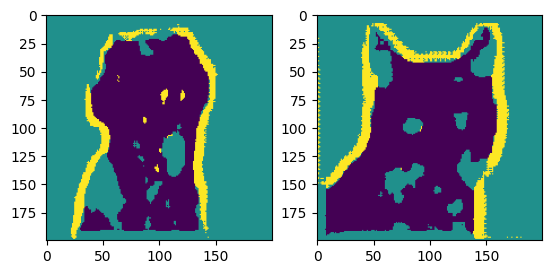

In [29]:
# display masked output

plt.subplot(1, 2, 1)
plt.imshow(masked_image1)

plt.subplot(1, 2, 2)
plt.imshow(masked_image2)